# 07 - Conformal Prediction for Individual Treatment Effects

The repo's existing uncertainty tools cover the *metric* level (bootstrap Qini CIs and tiers, notebook 06) and the *CATE function* level (Causal Forest bootstrap-of-little-bags CIs, notebook 02). This notebook targets the third and hardest level: **predictive intervals for the individual treatment effect** ITE = Y(1) - Y(0) of a new unit, with finite-sample, distribution-free guarantees from conformal prediction.

Two established routes exist:

- **Counterfactual route** (Lei and Candes, JRSS-B 2021): conformal intervals for Y(1) and Y(0) separately, contrasted into an ITE interval. Uses weighted conformal prediction, but in a completely randomized experiment the propensity is constant and *the weights collapse away* (their Sec. 3.4) - plain split conformal is finite-sample valid.
- **Pseudo-outcome route** (Alaa, Ahmad, van der Laan, NeurIPS 2023, "conformal meta-learners"): conformalize a regression on doubly-robust pseudo-outcomes. Guarantees pseudo-outcome coverage always; ITE coverage follows for DR/IPW pseudo-outcomes via stochastic dominance.

We implement the pseudo-outcome route (simpler under an RCT, and the pseudo-outcome is computable for every unit) and study what a **rare binary outcome** (conversion ~ 0.3%) does to it. Spoiler: the marginal ITE coverage guarantee is real but nearly vacuous here, and the interesting structure is in *where* the intervals get their width. A semi-synthetic experiment with planted outcomes then shows the same pipeline working non-trivially when the outcome carries enough signal, and degenerating in a controlled way at a comparably rare base rate.

## Setup

Same conventions as notebooks 00-06: 500K-row sample, seed 42, stratified 20% hold-out. No new dependencies - split conformal is implemented inline (the method is ~10 lines).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from criteo_data import fetch_criteo

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
SAMPLE_SIZE = 500_000

LGBM_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

In [2]:
print('Loading Criteo dataset...')
dataset = fetch_criteo(target_col='conversion')
X_full, y_full, treat_full = dataset.data, dataset.target, dataset.treatment

# Re-seed right before the draw: reproduces the same 500K subsample as
# notebooks 01-06, hence the same stratified hold-out.
np.random.seed(SEED)
if SAMPLE_SIZE and SAMPLE_SIZE < len(X_full):
    idx = np.random.choice(len(X_full), SAMPLE_SIZE, replace=False)
    X_full = X_full.iloc[idx].reset_index(drop=True)
    y_full = y_full.iloc[idx].reset_index(drop=True)
    treat_full = treat_full.iloc[idx].reset_index(drop=True)

strat_key = treat_full.values * 2 + y_full.values
(X_train, X_test,
 y_train, y_test,
 t_train, t_test) = train_test_split(
    X_full.values, y_full.values, treat_full.values,
    test_size=0.2, random_state=SEED, stratify=strat_key)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Treatment share: {t_train.mean():.4f}   conversion rate: {y_train.mean():.5f}')

Loading Criteo dataset...


Train: 400,000  |  Test: 100,000
Treatment share: 0.8500   conversion rate: 0.00307


## Split conformal in ten lines

Fit any predictor on a training fold. On a *calibration* fold of size $n$, compute conformity scores $V_i = |y_i - \hat f(x_i)|$. Take

$$\hat q = \text{the } \lceil (n+1)(1-\alpha) \rceil / n \text{ empirical quantile of } V_1, \dots, V_n,$$

and predict $C(x) = \hat f(x) \pm \hat q$. If calibration and test points are exchangeable, then (Vovk; see Angelopoulos and Bates 2021, Thm 1.1)

$$1 - \alpha \;\le\; P\big(Y \in C(X)\big) \;\le\; 1 - \alpha + \tfrac{1}{n+1}.$$

The guarantee is **marginal** (averaged over X and the calibration draw), not conditional on $x$; distribution-free conditional coverage is provably impossible (Barber et al. 2019).

### Getting from outcomes to treatment effects

ITE is never observed, so conformal cannot calibrate on it directly. The **conformal meta-learner** protocol (Alaa et al. 2023, Algorithm 1) uses a three-way split of the training data:

1. $D_\phi$ - fit nuisances $\hat\mu_0, \hat\mu_1$ (and $\hat e$; here $e = 0.85$ is *known by design*, nothing to fit),
2. $D_\tau$ - fit a regression $\hat\tau(x)$ on the doubly-robust pseudo-outcome
$$\tilde Y_{DR} = \frac{(W - e)}{e(1-e)}\big(Y - \hat\mu_W(X)\big) + \hat\mu_1(X) - \hat\mu_0(X),$$
3. $D_{cal}$ - conformity scores $V_i = |\tilde Y_{DR,i} - \hat\tau(x_i)|$.

$\tilde Y_{DR}$ is computable for **every** unit from observed $(X, W, Y)$, so calibration and test scores are exchangeable by construction and *no covariate-shift weighting is needed* - in contrast to the counterfactual route, where weighting appears and then collapses only because the Criteo assignment is Bernoulli(0.85) independent of X (Lei and Candes, Sec. 3.4).

What is guaranteed: coverage of **pseudo-outcomes**, always (and it is observable, so we verify it below). Coverage of **ITE**: for DR and IPW pseudo-outcomes, Alaa et al. prove the calibration scores stochastically dominate the oracle ITE scores (their Thm 2), so ITE coverage holds for all practically relevant $\alpha$ - but as we will see, on rare binary outcomes that promise is much weaker than it sounds.

## Real data: the pipeline

Three-way split of the 400K training rows: 40% nuisances / 40% pseudo-outcome regression / 20% calibration, stratified on (treatment x conversion) as everywhere in this repo.

In [3]:
E = t_train.mean()  # 0.8500 - the known Bernoulli design probability

strat_tr = t_train * 2 + y_train
(X_phi, X_rest, y_phi, y_rest, t_phi, t_rest) = train_test_split(
    X_train, y_train, t_train, test_size=0.6, random_state=SEED, stratify=strat_tr)
strat_rest = t_rest * 2 + y_rest
(X_dtau, X_cal, y_dtau, y_cal, t_dtau, t_cal) = train_test_split(
    X_rest, y_rest, t_rest, test_size=1/3, random_state=SEED, stratify=strat_rest)

print(f'D_phi: {len(X_phi):,}   D_tau: {len(X_dtau):,}   D_cal: {len(X_cal):,}')

# Nuisances on D_phi only
mu0 = LGBMClassifier(**LGBM_PARAMS).fit(X_phi[t_phi == 0], y_phi[t_phi == 0])
mu1 = LGBMClassifier(**LGBM_PARAMS).fit(X_phi[t_phi == 1], y_phi[t_phi == 1])


def dr_pseudo(X, t, y, m0_model, m1_model, e):
    m0 = m0_model.predict_proba(X)[:, 1]
    m1 = m1_model.predict_proba(X)[:, 1]
    mw = np.where(t == 1, m1, m0)
    return (t - e) / (e * (1 - e)) * (y - mw) + m1 - m0


yd_dtau = dr_pseudo(X_dtau, t_dtau, y_dtau, mu0, mu1, E)
yd_cal  = dr_pseudo(X_cal,  t_cal,  y_cal,  mu0, mu1, E)
yd_test = dr_pseudo(X_test, t_test, y_test, mu0, mu1, E)

print(f'pseudo-outcome mean (D_tau): {yd_dtau.mean():+.5f}   (compare ATE ~ +0.0012)')

D_phi: 160,000   D_tau: 160,000   D_cal: 80,000


pseudo-outcome mean (D_tau): +0.00097   (compare ATE ~ +0.0012)


In [4]:
# CATE model on pseudo-outcomes + conformal calibration
tau_model = LGBMRegressor(**LGBM_PARAMS).fit(X_dtau, yd_dtau)

V_cal = np.abs(yd_cal - tau_model.predict(X_cal))


def conformal_qhat(scores, alpha):
    """Split-conformal quantile with the finite-sample correction."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    if k > n:
        return np.inf
    return np.sort(scores)[k - 1]


for alpha in [0.20, 0.10, 0.05]:
    q = conformal_qhat(V_cal, alpha)
    print(f'alpha={alpha:.2f}:  interval = tau_hat(x) +/- {q:.4f}')

alpha=0.20:  interval = tau_hat(x) +/- 0.0008
alpha=0.10:  interval = tau_hat(x) +/- 0.0029
alpha=0.05:  interval = tau_hat(x) +/- 0.0096


## The score geometry: four spikes

With a rare binary outcome the DR pseudo-outcome takes essentially four values. With $m_1 \approx p_1 = 0.0033$, $m_0 \approx p_0 = 0.0020$, $e = 0.85$:

| cell | pseudo-outcome | share of data |
|---|---|---|
| treated, Y=0 | ~ -0.003 | 84.7% |
| control, Y=0 | ~ +0.015 | 15.0% |
| treated, Y=1 | ~ +1.17 (spike ~ +1/e) | 0.28% |
| control, Y=1 | ~ -6.65 (spike ~ -1/(1-e)) | 0.03% |

99.7% of calibration scores are tiny; the rest sit at two spikes whose *location* is set purely by the design ratio: the price of an 85/15 split is the 1/(1-e) = 6.7 factor on rare control converters.

(The per-cell means printed below are conformity *scores* $|\tilde Y_{DR} - \hat\tau(x)|$, so they land a little below the raw pseudo-outcome magnitudes in the table above - $\hat\tau$ absorbs part of each spike.)

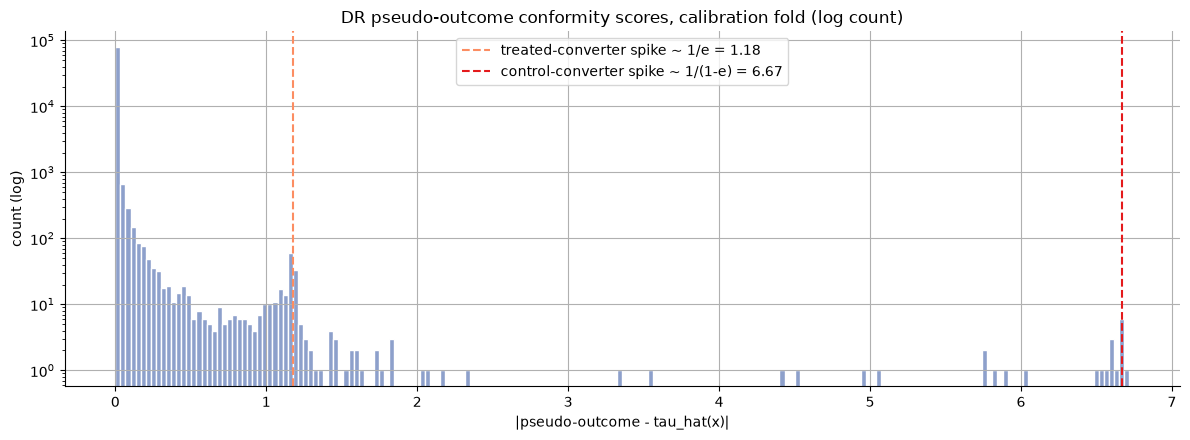

treated, Y=1:  n=   221   mean score=1.0594
control, Y=1:  n=    24   mean score=5.7345
treated, Y=0:  n=67,779   mean score=0.0035
control, Y=0:  n=11,976   mean score=0.0063


In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.hist(V_cal, bins=200, color='#8da0cb', edgecolor='white', log=True)
ax.axvline(1/E, color='#fc8d62', lw=1.5, ls='--',
           label=f'treated-converter spike ~ 1/e = {1/E:.2f}')
ax.axvline(1/(1-E), color='#e41a1c', lw=1.5, ls='--',
           label=f'control-converter spike ~ 1/(1-e) = {1/(1-E):.2f}')
ax.set_title('DR pseudo-outcome conformity scores, calibration fold (log count)')
ax.set_xlabel('|pseudo-outcome - tau_hat(x)|')
ax.set_ylabel('count (log)')
ax.legend()
plt.tight_layout()
plt.savefig('07_conformal_scores.png', dpi=140, bbox_inches='tight')
plt.show()

for name, mask in [('treated, Y=1', (t_cal == 1) & (y_cal == 1)),
                   ('control, Y=1', (t_cal == 0) & (y_cal == 1)),
                   ('treated, Y=0', (t_cal == 1) & (y_cal == 0)),
                   ('control, Y=0', (t_cal == 0) & (y_cal == 0))]:
    print(f'{name}:  n={mask.sum():>6,}   mean score={V_cal[mask].mean():.4f}')

## The width staircase

Because the score distribution is almost discrete, the conformal quantile $\hat q$ jumps as the target coverage crosses the spike masses. Until $1-\alpha$ exceeds ~99.7%, the intervals are a few thousandths wide; past it they must absorb treated converters (width jumps to ~1.2); past ~99.97% they must absorb control converters (width ~6.7).

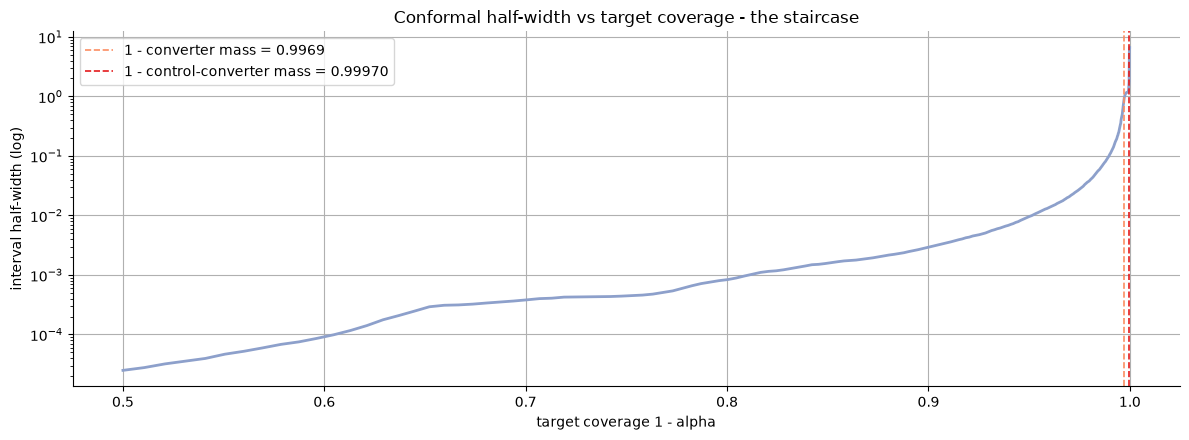

In [6]:
levels = 1 - np.logspace(np.log10(0.5), np.log10(0.0001), 400)
widths = np.array([conformal_qhat(V_cal, 1 - lv) for lv in levels])

fig, ax = plt.subplots(figsize=(12, 4.5))
finite = np.isfinite(widths)
ax.plot(levels[finite], widths[finite], color='#8da0cb', lw=2)
ax.set_yscale('log')
ax.set_title('Conformal half-width vs target coverage - the staircase')
ax.set_xlabel('target coverage 1 - alpha')
ax.set_ylabel('interval half-width (log)')
share_tc = ((t_cal == 1) & (y_cal == 1)).mean()
share_cc = ((t_cal == 0) & (y_cal == 1)).mean()
ax.axvline(1 - share_tc - share_cc, color='#fc8d62', ls='--', lw=1.2,
           label=f'1 - converter mass = {1 - share_tc - share_cc:.4f}')
ax.axvline(1 - share_cc, color='#e41a1c', ls='--', lw=1.2,
           label=f'1 - control-converter mass = {1 - share_cc:.5f}')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('07_conformal_staircase.png', dpi=140, bbox_inches='tight')
plt.show()

## What the guarantee actually promises: pseudo-outcome coverage

The CP theorem guarantees coverage of *pseudo-outcomes*, and pseudo-outcomes are observable on the hold-out - so this claim is empirically checkable, at every $\alpha$. This is the honest, verifiable statement conformal makes on this dataset.

(The near-zero width at $\alpha = 0.5$ is real, not a bug: for the 85% of units that are treated non-converters the pseudo-outcome is a smooth deterministic function of $x$, which the pseudo-outcome regression fits almost exactly, so half of all conformity scores are microscopic.)

In [7]:
tau_test = tau_model.predict(X_test)
V_test = np.abs(yd_test - tau_test)

rows = []
for alpha in [0.50, 0.20, 0.10, 0.05, 0.01, 0.005, 0.001]:
    q = conformal_qhat(V_cal, alpha)
    cov = (V_test <= q).mean() if np.isfinite(q) else 1.0
    rows.append({'alpha': alpha, 'nominal': 1 - alpha,
                 'half-width': q, 'empirical coverage': cov})
cov_df = pd.DataFrame(rows)
print(cov_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

 alpha  nominal  half-width  empirical coverage
0.5000   0.5000      0.0000              0.5029
0.2000   0.8000      0.0008              0.8020
0.1000   0.9000      0.0029              0.9006
0.0500   0.9500      0.0096              0.9516
0.0100   0.9900      0.1052              0.9903
0.0050   0.9950      0.2996              0.9948
0.0010   0.9990      1.1764              0.9989


## The honest ITE readout

For a binary outcome, ITE takes values in {-1, 0, +1}, and

$$P(\text{ITE} = 0) \ge 1 - p_1 - p_0.$$

Zhang and Richardson (2025) give the exact condition: the singleton set $\{0\}$ is a valid $1-\alpha$ prediction set for ITE precisely when the mass of affected units (helped + hurt) is below $\alpha$. On Criteo that mass is at most $p_1 + p_0 \approx 0.005$, far below any conventional $\alpha$. So:

- a "valid 95% ITE interval" can be the empty-of-information $\{0\}$,
- our conformal intervals at $\alpha = 0.05$ (half-width ~ 0.01) contain 0 for ~96% of test units - valid largely for the same trivial reason,
- intervals only become *informative about converters* past the staircase jumps, i.e. at coverage levels no one requests.

This is not a failure of conformal prediction; it is the marginal-coverage target being nearly vacuous when the affected stratum is rare - the same mechanism as minority-class under-coverage in conformal classification. The practical alternatives on such data: verify pseudo-outcome coverage (above), report group-level inference (bootstrap tiers of notebook 06, GATES-style quantile-group ATEs), or bound P(benefit) directly.

In [8]:
p1, p0 = y_test[t_test == 1].mean(), y_test[t_test == 0].mean()
q05 = conformal_qhat(V_cal, 0.05)
contains_zero = (np.abs(tau_test) <= q05).mean()

print(f'p1 = {p1:.5f}   p0 = {p0:.5f}')
print(f'P(ITE = 0) >= 1 - p1 - p0 = {1 - p1 - p0:.5f}')
print(f'=> the trivial set {{0}} already has >= {100 * (1 - p1 - p0):.2f}% ITE coverage')
print(f'alpha = 0.05 interval: half-width {q05:.4f}; contains 0 for '
      f'{100 * contains_zero:.2f}% of test units')

p1 = 0.00325   p0 = 0.00200
P(ITE = 0) >= 1 - p1 - p0 = 0.99475
=> the trivial set {0} already has >= 99.48% ITE coverage
alpha = 0.05 interval: half-width 0.0096; contains 0 for 96.10% of test units


## Semi-synthetic: the same pipeline where coverage is checkable

True ITEs are unobservable on real data, so every paper in this literature validates coverage on planted outcomes (Lei-Candes and Alaa et al. both use the NLSM/IHDP recipe: real covariates, synthetic potential outcomes). We do the same on real Criteo features, with the real Bernoulli(0.85) assignment. No public conformal-ITE coverage benchmark on Criteo covariates existed at the time of writing.

**Variant A (continuous outcome):** smooth baseline and effect surfaces on rank-transformed features (f8 and f4 drive the effect, matching this repo's HTE analysis), heteroscedastic noise. Here the pseudo-outcome carries real signal and conformal should deliver near-nominal, non-trivial ITE coverage.

**Variant B (binary outcome, comparably rare):** same effect geometry pushed through Bernoulli draws. The base coefficients ($p_0$ base $0.002$, $\tau$ base $0.001$) are multiplied by feature terms whose mean is below 1 (f0 and f2 are negatively correlated on Criteo, so their link product averages ~0.47), so the *realized* rates are ~0.1% control and ~0.2% treated - the same order as Criteo's real 0.2% / 0.3%, rare enough to reproduce the degeneration. Ground-truth strata are known here, so what is unobservable on real data can be checked under full control.

In [9]:
rng = np.random.RandomState(SEED)
N_SS = 200_000
idx_ss = rng.choice(len(X_train), N_SS, replace=False)
Xs = X_train[idx_ss]


def unit_rank(v):
    order = pd.Series(v).rank(method='average').values
    return order / (len(order) + 1)


def link(u):
    # Lei-Candes smooth link: mean 1 over U(0,1)
    return 2 / (1 + np.exp(-12 * (u - 0.5)))


u0, u2 = unit_rank(Xs[:, 0]), unit_rank(Xs[:, 2])
u4, u8 = unit_rank(Xs[:, 4]), unit_rank(Xs[:, 8])

# --- Variant A: continuous
m0_true = link(u0) * link(u2)
tau_true = link(u8) * link(u4) / 2.0
sigma = 0.2 * (1 + u2)
Y0a = m0_true + sigma * rng.randn(N_SS)
Y1a = m0_true + tau_true + sigma * rng.randn(N_SS)
Ta = rng.binomial(1, 0.85, N_SS)
Ya = np.where(Ta == 1, Y1a, Y0a)
ITEa = Y1a - Y0a

print(f'Variant A: tau range [{tau_true.min():.3f}, {tau_true.max():.3f}], '
      f'mean {tau_true.mean():.3f}; noise sd ~ {sigma.mean():.3f}')

Variant A: tau range [0.002, 0.823], mean 0.472; noise sd ~ 0.300


In [10]:
def conformal_dr_run(X, Y, T, ITE, e, regression=True, alphas=(0.20, 0.10, 0.05)):
    """Full conformal meta-learner pass; returns per-alpha ITE/pseudo coverage."""
    n = len(X)
    rs = np.random.RandomState(SEED)
    perm = rs.permutation(n)
    i_phi, i_tau = perm[:int(0.35 * n)], perm[int(0.35 * n):int(0.70 * n)]
    i_cal, i_te = perm[int(0.70 * n):int(0.85 * n)], perm[int(0.85 * n):]

    if regression:
        m0 = LGBMRegressor(**LGBM_PARAMS).fit(X[i_phi][T[i_phi] == 0], Y[i_phi][T[i_phi] == 0])
        m1 = LGBMRegressor(**LGBM_PARAMS).fit(X[i_phi][T[i_phi] == 1], Y[i_phi][T[i_phi] == 1])
        pred0 = lambda Z: m0.predict(Z)
        pred1 = lambda Z: m1.predict(Z)
    else:
        m0 = LGBMClassifier(**LGBM_PARAMS).fit(X[i_phi][T[i_phi] == 0], Y[i_phi][T[i_phi] == 0])
        m1 = LGBMClassifier(**LGBM_PARAMS).fit(X[i_phi][T[i_phi] == 1], Y[i_phi][T[i_phi] == 1])
        pred0 = lambda Z: m0.predict_proba(Z)[:, 1]
        pred1 = lambda Z: m1.predict_proba(Z)[:, 1]

    def pseudo(ii):
        mw = np.where(T[ii] == 1, pred1(X[ii]), pred0(X[ii]))
        return (T[ii] - e) / (e * (1 - e)) * (Y[ii] - mw) + pred1(X[ii]) - pred0(X[ii])

    tau_m = LGBMRegressor(**LGBM_PARAMS).fit(X[i_tau], pseudo(i_tau))
    Vc = np.abs(pseudo(i_cal) - tau_m.predict(X[i_cal]))
    tau_te = tau_m.predict(X[i_te])
    yd_te = pseudo(i_te)

    out = []
    for a in alphas:
        q = conformal_qhat(Vc, a)
        out.append({
            'alpha': a, 'nominal': 1 - a, 'half-width': q,
            'ITE coverage': (np.abs(ITE[i_te] - tau_te) <= q).mean(),
            'pseudo coverage': (np.abs(yd_te - tau_te) <= q).mean(),
        })
    aux = {'Vc': Vc, 'i_te': i_te, 'tau_te': tau_te}
    return pd.DataFrame(out), aux


res_a, aux_a = conformal_dr_run(Xs, Ya, Ta, ITEa, 0.85)
print('Variant A (continuous outcome):')
print(res_a.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

Variant A (continuous outcome):
 alpha  nominal  half-width  ITE coverage  pseudo coverage
0.2000   0.8000      0.6050        0.8423           0.8013
0.1000   0.9000      1.0175        0.9756           0.9018
0.0500   0.9500      1.9209        0.9999           0.9507


On the continuous variant the intervals are non-trivial (width comparable to the noise scale, not to the outcome range) and ITE coverage sits above nominal, increasingly conservative at higher levels - the direction Alaa et al. predict, since pseudo-outcome scores stochastically dominate oracle ITE scores. Pseudo-outcome coverage stays tight to nominal throughout. This is the machinery working as designed.

In [11]:
# --- Variant B: binary, comparably rare base rate
p0_true = 0.002 * link(u0) * link(u2)
tau_b_true = 0.001 * link(u8) * link(u4)
p1_true = np.clip(p0_true + tau_b_true, 0, 1)
Y0b = (rng.rand(N_SS) < p0_true).astype(int)
Y1b = (rng.rand(N_SS) < p1_true).astype(int)
Tb = rng.binomial(1, 0.85, N_SS)
Yb = np.where(Tb == 1, Y1b, Y0b)
ITEb = Y1b - Y0b
print(f'realized rate: control {Yb[Tb == 0].mean():.5f}, treated {Yb[Tb == 1].mean():.5f}')

strata = pd.Series(ITEb).value_counts(normalize=True).sort_index()
print('Variant B true ITE strata:')
print(strata.rename({-1: 'hurt (-1)', 0: 'unaffected (0)', 1: 'helped (+1)'})
      .to_string(float_format=lambda v: f'{v:.5f}'))

res_b, aux_b = conformal_dr_run(Xs, Yb, Tb, ITEb, 0.85, regression=False)
print('\nVariant B (binary outcome):')
print(res_b.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# Marginal coverage looks healthy; the stratum breakdown shows how it is earned.
q10 = conformal_qhat(aux_b['Vc'], 0.10)
ite_te = ITEb[aux_b['i_te']]
covered = np.abs(ite_te - aux_b['tau_te']) <= q10
affected = ite_te != 0
print(f'\nalpha = 0.10 stratum breakdown:')
print(f'  unaffected (ITE = 0):  coverage {covered[~affected].mean():.4f}   (n={np.sum(~affected):,})')
print(f'  affected  (|ITE| = 1): coverage {covered[affected].mean():.4f}   (n={affected.sum():,})')

realized rate: control 0.00087, treated 0.00194
Variant B true ITE strata:
hurt (-1)        0.00099
unaffected (0)   0.99701
helped (+1)      0.00200



Variant B (binary outcome):
 alpha  nominal  half-width  ITE coverage  pseudo coverage
0.2000   0.8000      0.0033        0.8308           0.8046
0.1000   0.9000      0.0061        0.9109           0.9034
0.0500   0.9500      0.0121        0.9550           0.9513

alpha = 0.10 stratum breakdown:
  unaffected (ITE = 0):  coverage 0.9135   (n=29,916)
  affected  (|ITE| = 1): coverage 0.0000   (n=84)


Variant B closes the loop with a sharper twist than mere saturation. **Marginal ITE coverage looks perfectly healthy - it tracks nominal.** The stratum breakdown shows how that is earned: the intervals are a few thousandths wide, they cover unaffected units (ITE = 0) and they *never* contain -1 or +1, so conditional coverage on the affected stratum is exactly zero at every conventional level. Marginal validity is real, and information about precisely the units uplift modeling exists to find is absent. This is the minority-class under-coverage mechanism of conformal classification transplanted to ITE - with the crucial difference that class-conditional (Mondrian) fixes are unavailable, because stratum membership is unobservable even in training. On real Criteo data this breakdown cannot be computed; here the planted ground truth makes it exact.

## Contrast: CATE-function CIs are a different promise

Causal Forest bootstrap-of-little-bags CIs (notebook 02) cover the *conditional mean* $\tau(x)$, not the realization $Y(1)-Y(0)$. On variant A both targets are known, so the difference is directly visible: BLB intervals are narrow and cover $\tau(x)$; conformal intervals are wide because they must absorb outcome noise to cover the ITE realization. Neither is "better" - they answer different questions.

In [12]:
from econml.grf import CausalForest

n_grf = 50_000
i_grf = np.random.RandomState(SEED).choice(len(Xs), n_grf, replace=False)
i_fit, i_eval = i_grf[:40_000], i_grf[40_000:]

cf = CausalForest(n_estimators=500, min_samples_leaf=20, max_depth=None,
                  inference=True, random_state=SEED, n_jobs=-1)
cf.fit(Xs[i_fit], Ta[i_fit], Ya[i_fit])
tau_pt, tau_lb, tau_ub = cf.predict(Xs[i_eval], interval=True, alpha=0.10)
tau_pt, tau_lb, tau_ub = tau_pt.flatten(), tau_lb.flatten(), tau_ub.flatten()

blb_cov_tau = ((tau_true[i_eval] >= tau_lb) & (tau_true[i_eval] <= tau_ub)).mean()
blb_cov_ite = ((ITEa[i_eval] >= tau_lb) & (ITEa[i_eval] <= tau_ub)).mean()
blb_width = (tau_ub - tau_lb).mean()

q10_a = res_a.loc[res_a['alpha'] == 0.10, 'half-width'].iloc[0]
print(f'90% BLB CI:        mean width {blb_width:.3f}   '
      f'covers tau(x): {blb_cov_tau:.3f}   covers ITE realization: {blb_cov_ite:.3f}')
print(f'90% conformal:     width {2 * q10_a:.3f}   covers ITE realization: '
      f"{res_a.loc[res_a['alpha'] == 0.10, 'ITE coverage'].iloc[0]:.3f}")

90% BLB CI:        mean width 0.169   covers tau(x): 0.885   covers ITE realization: 0.157
90% conformal:     width 2.035   covers ITE realization: 0.976


## Takeaways

| object of inference | method | guarantee | verdict on Criteo |
|---|---|---|---|
| ATE | AIPW influence-function CI (nb 04) | asymptotic | works; CI [-0.0002, 0.0011] |
| leaderboard metric | stratified paired bootstrap (nb 06) | resampling | works; most models tied |
| CATE function tau(x) | Causal Forest BLB CI (nb 02) | asymptotic, forest-specific | ~90% of 90% CIs straddle 0 (10% confident persuadables) |
| ITE realization | conformal meta-learner (this nb) | finite-sample, distribution-free, marginal | valid but nearly vacuous at conventional alpha |
| pseudo-outcome | split conformal (this nb) | finite-sample, verifiable | tracks nominal - the checkable claim |

1. **The machinery is simple and sound.** Split conformal on DR pseudo-outcomes needs no weighting in an RCT, ~10 lines of code, and its verifiable guarantee (pseudo-outcome coverage) holds on the hold-out at every alpha we tested.
2. **Rare binary outcomes make marginal ITE coverage nearly vacuous.** With P(ITE = 0) > 99.4%, the trivial set {0} is already "valid" at any conventional level (Zhang-Richardson condition). Interval width is a staircase whose steps sit at coverage levels no one requests, and whose heights (1/e, 1/(1-e)) are set by the design ratio, not by the model.
3. **Marginal coverage can be exactly on target and still say nothing about the units that matter.** On planted continuous outcomes over real Criteo features, ITE coverage is at-or-above nominal with informative widths. Pushing the same effect through a comparably rare Bernoulli outcome (realized ~0.1% control / ~0.2% treated) keeps marginal ITE coverage nominal while conditional coverage on the affected stratum (the persuadables and sleeping dogs) drops to exactly zero - and no Mondrian-style fix exists, because stratum membership is unobservable.
4. **Ask the right question of the right tool.** BLB CIs answer "where is tau(x)"; conformal answers "where will Y(1)-Y(0) land". On rare binary conversions, the practical uncertainty statements are group-level (bootstrap tiers, quantile-group ATEs) or bounds on P(benefit) - individual-level intervals are structurally uninformative, and no method fixes that.